NAME : - LALIT PATHADE

ROLL NO :-58

PRN :-12411458

DIV :-CSAI , BATCH 3

ASSIGNMENT - 2


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


dirty dataset


In [ ]:
data = {
    'ID': [1,2,3,4,5,6,7,8,9,10,10,12,13,14,15,16,17,18,19,20],
    'Name': [' Amit','neha','RAHUL','Pooja ',None,'Karan','Neha','rahul','AMIT','pooja',
             'pooja','Kiran','Amit','Neha ','RAHUL','Pooja','Karan','Neha',None,'Amit'],
    'Age': [22,25,None,24,0,35,25,120,22,24,24,30,None,28,35,40,22,25,0,60],
    'Salary': [25000,30000,None,35000,0,50000,30000,999999,25000,35000,
               35000,40000,None,28000,50000,60000,25000,30000,0,70000],
    'JoinDate': ['2023-01-10','2023-02-15',None,'2023-03-20','2023-04-01',
                 '2023-05-10','2023-02-15','2020-01-01','2023-01-10','2023-03-20',
                 '2023-03-20','2023-06-01','2023-07-01','2023-08-01','2023-09-01',
                 '2023-10-01','2023-11-01','2023-12-01','2023-04-01','2023-05-10'],
    'Department': ['IT','HR','IT','HR','Sales','IT','HR','IT','IT','HR',
                   'HR','Sales','IT','Sales','IT','HR','IT','HR','Sales','IT']
}

df = pd.DataFrame(data)
df


,ID,Name,Age,Salary,JoinDate,Department
0,1,Amit,22.0,25000.0,2023-01-10,IT
1,2,neha,25.0,30000.0,2023-02-15,HR
2,3,RAHUL,NaN,NaN,None,IT
3,4,Pooja,24.0,35000.0,2023-03-20,HR
4,5,None,0.0,0.0,2023-04-01,Sales
5,6,Karan,35.0,50000.0,2023-05-10,IT
6,7,Neha,25.0,30000.0,2023-02-15,HR
7,8,rahul,120.0,999999.0,2020-01-01,IT
8,9,AMIT,22.0,25000.0,2023-01-10,IT
9,10,pooja,24.0,35000.0,2023-03-20,HR


Handling missing values

In [ ]:
df.isnull()
df.isnull().sum()
df.notnull()
df.dropna()
df.interpolate()


/tmp/ipython-input-4112436553.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate()


,ID,Name,Age,Salary,JoinDate,Department
0,1,Amit,22.0,25000.0,2023-01-10,IT
1,2,neha,25.0,30000.0,2023-02-15,HR
2,3,RAHUL,24.5,32500.0,None,IT
3,4,Pooja,24.0,35000.0,2023-03-20,HR
4,5,None,0.0,0.0,2023-04-01,Sales
5,6,Karan,35.0,50000.0,2023-05-10,IT
6,7,Neha,25.0,30000.0,2023-02-15,HR
7,8,rahul,120.0,999999.0,2020-01-01,IT
8,9,AMIT,22.0,25000.0,2023-01-10,IT
9,10,pooja,24.0,35000.0,2023-03-20,HR


MIN,MAX,MEAN,STD-DEV,VARIANCE,RANGE,QUARTILES

In [ ]:
summary_stats = pd.DataFrame({
    "Mean": df.mean(numeric_only=True),
    "Std_Deviation": df.std(numeric_only=True),
    "Variance": df.var(numeric_only=True),
    "Minimum": df.min(numeric_only=True),
    "Maximum": df.max(numeric_only=True),
    "Range": df.max(numeric_only=True) - df.min(numeric_only=True),
    "25%": df.quantile(0.25, numeric_only=True),
    "50% (Median)": df.quantile(0.50, numeric_only=True),
    "75%": df.quantile(0.75, numeric_only=True)
})

summary_stats


,Mean,Std_Deviation,Variance,Minimum,Maximum,Range,25%,50% (Median),75%
ID,10.450000,5.915857,3.499737e+01,1.0,20.0,19.0,5.75,10.0,15.25
Age,31.166667,25.787024,6.649706e+02,0.0,120.0,120.0,22.50,25.0,33.75
Salary,87111.055556,228491.466181,5.220835e+10,0.0,999999.0,999999.0,25750.00,32500.0,47500.00


user define for variance


In [ ]:
# Select numeric columns safely
numeric_df = df.select_dtypes(include='number')

print("\nVariance of each numeric column (manual calculation):")

for col in numeric_df.columns:
    # Remove NaN values
    values = numeric_df[col].dropna().tolist()
    n = len(values)

    if n == 0:
        print(col, ": No valid data")
        continue

    # Step 1: Calculate mean manually
    total = 0
    for v in values:
        total += v
    mean_val = total / n

    # Step 2: Calculate variance manually
    variance = 0
    for v in values:
        variance += (v - mean_val) ** 2
    variance = variance / n   # population variance

    print(col, ":", variance)



Variance of each numeric column (manual calculation):
ID : 33.247499999999995
Age : 628.0277777777777
Salary : 49307886222.274704


HISTOGRAMS

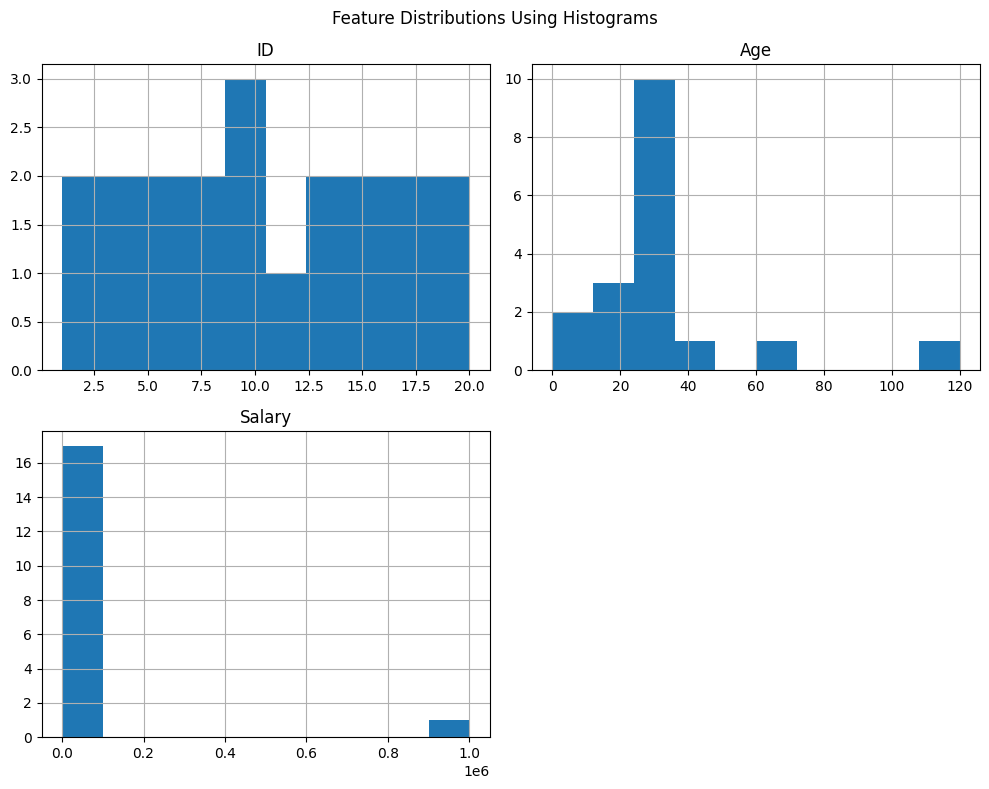

In [ ]:
df.hist(figsize=(10, 8))
plt.suptitle("Feature Distributions Using Histograms")
plt.tight_layout()
plt.show()


HIST

Remove missing rows

In [ ]:
df_dropna = df.dropna()


fill missing values

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Salary'] = df['Salary'].fillna(df['Salary'].mean())


replace NaN

In [ ]:
df.replace(np.nan, 'Unknown', inplace=True)


Removing duplicates

In [ ]:
df.duplicated()
df = df.drop_duplicates()


Data type Conversion

In [ ]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')
df['JoinDate'] = pd.to_datetime(df['JoinDate'], errors='coerce')
df = df.convert_dtypes()


/tmp/ipython-input-4242763687.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
/tmp/ipython-input-4242763687.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')
/tmp/ipython-input-4242763687.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pan

RENAMING COLUMNS & INDEX

In [ ]:
df.rename(columns={'Salary':'MonthlySalary'}, inplace=True)
df.add_prefix('EMP_')
df.add_suffix('_INFO')


,ID_INFO,Name_INFO,Age_INFO,MonthlySalary_INFO,JoinDate_INFO,Department_INFO
0,1,Amit,22.0,25000.0,2023-01-10,IT
1,2,neha,25.0,30000.0,2023-02-15,HR
2,3,RAHUL,31.166667,87111.055556,NaT,IT
3,4,Pooja,24.0,35000.0,2023-03-20,HR
4,5,Unknown,0.0,0.0,2023-04-01,Sales
5,6,Karan,35.0,50000.0,2023-05-10,IT
6,7,Neha,25.0,30000.0,2023-02-15,HR
7,8,rahul,120.0,999999.0,2020-01-01,IT
8,9,AMIT,22.0,25000.0,2023-01-10,IT
9,10,pooja,24.0,35000.0,2023-03-20,HR


HANDLING INCORRECT / INCONSISTENT DATA

In [ ]:

df['Name'] = df['Name'].replace('Unknown', 'NotAvailable')

df['Department'] = df['Department'].map({
    'IT': 'Information Technology',
    'HR': 'Human Resources',
    'Sales': 'Sales'
})

df['Age'] = df['Age'].apply(lambda x: x if x < 100 else np.nan)

df = df[df['Age'] >= 18]

df['MonthlySalary'] = df['MonthlySalary'].mask(df['MonthlySalary'] < 0)



STRING CLEANING

In [ ]:
df['Name'] = df['Name'].str.strip()
df['Name'] = df['Name'].str.lower()
df['Name'] = df['Name'].str.title()

df['Name'].str.len()
df['Name'].str.contains('Amit')


,Name
0,True
1,False
2,False
3,False
5,False
6,False
8,True
9,False
11,False
12,True


HANDLING OUTLIERS

In [ ]:

df.describe()


df['MonthlySalary'].quantile([0.25, 0.75])


df['MonthlySalary'] = df['MonthlySalary'].clip(20000, 80000)


df['Age'].between(18, 60)


,Age
0,True
1,True
2,True
3,True
5,True
6,True
8,True
9,True
11,True
12,True


INDEX & ROW OPERATIONS

In [ ]:

df = df.reset_index(drop=True)

df = df.set_index('ID')

df = df.reindex(df.index)

df = df.sort_index()

df.head()



,Name,Age,MonthlySalary,JoinDate,Department
ID,,,,,
1,Amit,22.000000,25000.0,2023-01-10,Information Technology
2,Neha,25.000000,30000.0,2023-02-15,Human Resources
3,Rahul,31.166667,80000.0,NaT,Information Technology
4,Pooja,24.000000,35000.0,2023-03-20,Human Resources
6,Karan,35.000000,50000.0,2023-05-10,Information Technology


SORTING & FILTERING DATA

In [ ]:

df.sort_values(by='MonthlySalary')


df[df['Age'] > 30]


df.query("MonthlySalary > 40000")


df.loc[df['Department'] == 'IT']


df.iloc[0:5]


df.filter(like='Age')



/tmp/ipython-input-3022373700.py:7: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  df.query("MonthlySalary > 40000")


,Age
ID,
1,22.000000
2,25.000000
3,31.166667
4,24.000000
6,35.000000
7,25.000000
9,22.000000
10,24.000000
12,30.000000


DATA VALIDATION AND INSPECTION

In [ ]:
print("----- DATAFRAME INFO -----")
df.info()

print("\n----- FIRST 5 ROWS -----")
display(df.head())

print("\n----- LAST 5 ROWS -----")
display(df.tail())

print("\n----- RANDOM SAMPLE (5 ROWS) -----")
display(df.sample(5))

print("\n----- SHAPE (ROWS, COLUMNS) -----")
print(df.shape)

print("\n----- COLUMN NAMES -----")
print(df.columns)

print("\n----- DATA TYPES -----")
print(df.dtypes)

print("\n----- UNIQUE VALUES COUNT -----")
print(df.nunique())

print("\n----- VALUE COUNTS (Department) -----")
print(df['Department'].value_counts())




----- DATAFRAME INFO -----
<class 'pandas.core.frame.DataFrame'>
Index: 16 entries, 1 to 20
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Name           16 non-null     string        
 1   Age            16 non-null     float64       
 2   MonthlySalary  16 non-null     Float64       
 3   JoinDate       15 non-null     datetime64[ns]
 4   Department     16 non-null     object        
dtypes: Float64(1), datetime64[ns](1), float64(1), object(1), string(1)
memory usage: 800.0+ bytes

----- FIRST 5 ROWS -----


,Name,Age,MonthlySalary,JoinDate,Department
ID,,,,,
1,Amit,22.000000,25000.0,2023-01-10,Information Technology
2,Neha,25.000000,30000.0,2023-02-15,Human Resources
3,Rahul,31.166667,80000.0,NaT,Information Technology
4,Pooja,24.000000,35000.0,2023-03-20,Human Resources
6,Karan,35.000000,50000.0,2023-05-10,Information Technology



----- LAST 5 ROWS -----


,Name,Age,MonthlySalary,JoinDate,Department
ID,,,,,
15,Rahul,35.0,50000.0,2023-09-01,Information Technology
16,Pooja,40.0,60000.0,2023-10-01,Human Resources
17,Karan,22.0,25000.0,2023-11-01,Information Technology
18,Neha,25.0,30000.0,2023-12-01,Human Resources
20,Amit,60.0,70000.0,2023-05-10,Information Technology



----- RANDOM SAMPLE (5 ROWS) -----


,Name,Age,MonthlySalary,JoinDate,Department
ID,,,,,
12,Kiran,30.000000,40000.0,2023-06-01,Sales
13,Amit,31.166667,80000.0,2023-07-01,Information Technology
9,Amit,22.000000,25000.0,2023-01-10,Information Technology
18,Neha,25.000000,30000.0,2023-12-01,Human Resources
16,Pooja,40.000000,60000.0,2023-10-01,Human Resources



----- SHAPE (ROWS, COLUMNS) -----
(16, 5)

----- COLUMN NAMES -----
Index(['Name', 'Age', 'MonthlySalary', 'JoinDate', 'Department'], dtype='object')

----- DATA TYPES -----
Name             string[python]
Age                     float64
MonthlySalary           Float64
JoinDate         datetime64[ns]
Department               object
dtype: object

----- UNIQUE VALUES COUNT -----
Name              6
Age               9
MonthlySalary     9
JoinDate         11
Department        3
dtype: int64

----- VALUE COUNTS (Department) -----
Department
Information Technology    8
Human Resources           6
Sales                     2
Name: count, dtype: int64


HANDLING CATEGORIAL DATA

In [ ]:



df['Department'] = df['Department'].astype('category')

print("\n----- CATEGORY LABELS -----")
print(df['Department'].cat.categories)

df['Department'] = df['Department'].cat.rename_categories({
    'IT': 'Information Technology',
    'HR': 'Human Resources',
    'Sales': 'Sales'
})

print("\n----- RENAMED CATEGORIES -----")
print(df['Department'].cat.categories)

df['Department_Code'] = df['Department'].cat.codes

print("\n----- CATEGORY CODES -----")
display(df[['Department', 'Department_Code']].head())

print("\n----- ONE HOT ENCODING -----")
display(pd.get_dummies(df, columns=['Department']))


----- CATEGORY LABELS -----
Index(['Human Resources', 'Information Technology', 'Sales'], dtype='object')

----- RENAMED CATEGORIES -----
Index(['Human Resources', 'Information Technology', 'Sales'], dtype='object')

----- CATEGORY CODES -----


,Department,Department_Code
ID,,
1,Information Technology,1
2,Human Resources,0
3,Information Technology,1
4,Human Resources,0
6,Information Technology,1



----- ONE HOT ENCODING -----


,Name,Age,MonthlySalary,JoinDate,Department_Code,Department_Human Resources,Department_Information Technology,Department_Sales
ID,,,,,,,,
1,Amit,22.000000,25000.0,2023-01-10,1,False,True,False
2,Neha,25.000000,30000.0,2023-02-15,0,True,False,False
3,Rahul,31.166667,80000.0,NaT,1,False,True,False
4,Pooja,24.000000,35000.0,2023-03-20,0,True,False,False
6,Karan,35.000000,50000.0,2023-05-10,1,False,True,False
7,Neha,25.000000,30000.0,2023-02-15,0,True,False,False
9,Amit,22.000000,25000.0,2023-01-10,1,False,True,False
10,Pooja,24.000000,35000.0,2023-03-20,0,True,False,False
12,Kiran,30.000000,40000.0,2023-06-01,2,False,False,True


HANDLING DATE AND TIME DATA

In [ ]:
df['JoinDate'] = pd.to_datetime(df['JoinDate'], errors='coerce')

print("----- YEAR -----")
print(df['JoinDate'].dt.year)

print("\n----- MONTH -----")
print(df['JoinDate'].dt.month)

print("\n----- DAY -----")
print(df['JoinDate'].dt.day)

print("\n----- HOUR (if available, else NaN) -----")
print(df['JoinDate'].dt.hour)

print("\n----- FORMATTED DATE (DD-MM-YYYY) -----")
print(df['JoinDate'].dt.strftime('%d-%m-%Y'))

print("\n----- TIMEZONE LOCALIZATION -----")
df['JoinDate_TZ'] = df['JoinDate'].dt.tz_localize('UTC')
print(df['JoinDate_TZ'].head())

print("\n----- TIMEZONE CONVERSION (UTC → Asia/Kolkata) -----")
df['JoinDate_IST'] = df['JoinDate_TZ'].dt.tz_convert('Asia/Kolkata')
print(df['JoinDate_IST'].head())

----- YEAR -----
ID
1     2023.0
2     2023.0
3        NaN
4     2023.0
6     2023.0
7     2023.0
9     2023.0
10    2023.0
12    2023.0
13    2023.0
14    2023.0
15    2023.0
16    2023.0
17    2023.0
18    2023.0
20    2023.0
Name: JoinDate, dtype: float64

----- MONTH -----
ID
1      1.0
2      2.0
3      NaN
4      3.0
6      5.0
7      2.0
9      1.0
10     3.0
12     6.0
13     7.0
14     8.0
15     9.0
16    10.0
17    11.0
18    12.0
20     5.0
Name: JoinDate, dtype: float64

----- DAY -----
ID
1     10.0
2     15.0
3      NaN
4     20.0
6     10.0
7     15.0
9     10.0
10    20.0
12     1.0
13     1.0
14     1.0
15     1.0
16     1.0
17     1.0
18     1.0
20    10.0
Name: JoinDate, dtype: float64

----- HOUR (if available, else NaN) -----
ID
1     0.0
2     0.0
3     NaN
4     0.0
6     0.0
7     0.0
9     0.0
10    0.0
12    0.0
13    0.0
14    0.0
15    0.0
16    0.0
17    0.0
18    0.0
20    0.0
Name: JoinDate, dtype: float64

----- FORMATTED DATE (DD-MM-YYYY) -----
ID
1   

REMOVING SELECTED COLUMNS

In [ ]:
df_dropped = df.drop(columns=['JoinDate_TZ'], errors='ignore')
print("\n----- AFTER DROPPING JoinDate_TZ COLUMN -----")
print(df_dropped.columns)


salary_column = df.pop('MonthlySalary')
print("\n----- POPPED COLUMN (MonthlySalary) -----")
print(salary_column.head())


print("\n----- FILTER COLUMNS CONTAINING 'Age' -----")
print(df.filter(like='Age'))

print("\n----- FILTER COLUMNS USING REGEX (Date) -----")
print(df.filter(regex='Date'))


----- AFTER DROPPING JoinDate_TZ COLUMN -----
Index(['Name', 'Age', 'MonthlySalary', 'JoinDate', 'Department',
       'Department_Code', 'JoinDate_IST'],
      dtype='object')

----- POPPED COLUMN (MonthlySalary) -----
ID
1    25000.0
2    30000.0
3    80000.0
4    35000.0
6    50000.0
Name: MonthlySalary, dtype: Float64

----- FILTER COLUMNS CONTAINING 'Age' -----
          Age
ID           
1   22.000000
2   25.000000
3   31.166667
4   24.000000
6   35.000000
7   25.000000
9   22.000000
10  24.000000
12  30.000000
13  31.166667
14  28.000000
15  35.000000
16  40.000000
17  22.000000
18  25.000000
20  60.000000

----- FILTER COLUMNS USING REGEX (Date) -----
     JoinDate               JoinDate_TZ              JoinDate_IST
ID                                                               
1  2023-01-10 2023-01-10 00:00:00+00:00 2023-01-10 05:30:00+05:30
2  2023-02-15 2023-02-15 00:00:00+00:00 2023-02-15 05:30:00+05:30
3         NaT                       NaT                       NaT
4 

STANDARDIZATION / NORMALIZATION

In [ ]:

numeric_df = df.select_dtypes(include='number')


print(numeric_df.mean())

print(numeric_df.std())

print(numeric_df.min())

print(numeric_df.max())

standardized_df = numeric_df.apply(
    lambda x: (x - x.mean()) / x.std()
)

display(standardized_df)



Age                29.958333
Department_Code     0.750000
dtype: float64
Age                9.646051
Department_Code    0.683130
dtype: float64
Age                22.0
Department_Code     0.0
dtype: float64
Age                60.0
Department_Code     2.0
dtype: float64


,Age,Department_Code
ID,,
1,-0.825035,0.365963
2,-0.514027,-1.097888
3,0.125267,0.365963
4,-0.617697,-1.097888
6,0.522666,0.365963
7,-0.514027,-1.097888
9,-0.825035,0.365963
10,-0.617697,-1.097888
12,0.004320,1.829813


COMBINING AND RESHAPING THE DATA

In [ ]:


df_safe = df.copy()

print(df_safe.columns)
print(df_safe.index.name)

print("\nCONCAT")
df_concat = pd.concat([df_safe, df_safe], axis=0)
display(df_concat.head())

print("\nMERGE")
df_reset = df_safe.reset_index()
df_merge = pd.merge(df_reset, df_reset, on='ID', suffixes=('_left', '_right'))
display(df_merge.head())

print("\nJOIN")
df_join = df_safe.join(df_safe, lsuffix='_L', rsuffix='_R')
display(df_join.head())

print("\nPIVOT")
df_pivot = df_reset.pivot(index='ID', columns='Department', values='Age')
display(df_pivot.head())

print("\nPIVOT TABLE")
df_pivot_table = df_safe.pivot_table(values='Age', index='Department', aggfunc='mean')
display(df_pivot_table)

print("\nMELT")
df_melt = df_reset.melt(
    id_vars=['ID', 'Name'],
    value_vars=[c for c in ['Age', 'MonthlySalary'] if c in df_reset.columns]
)
display(df_melt.head())



Index(['Name', 'Age', 'JoinDate', 'Department', 'Department_Code',
       'JoinDate_TZ', 'JoinDate_IST'],
      dtype='object')
ID

CONCAT


,Name,Age,JoinDate,Department,Department_Code,JoinDate_TZ,JoinDate_IST
ID,,,,,,,
1,Amit,22.000000,2023-01-10,Information Technology,1,2023-01-10 00:00:00+00:00,2023-01-10 05:30:00+05:30
2,Neha,25.000000,2023-02-15,Human Resources,0,2023-02-15 00:00:00+00:00,2023-02-15 05:30:00+05:30
3,Rahul,31.166667,NaT,Information Technology,1,NaT,NaT
4,Pooja,24.000000,2023-03-20,Human Resources,0,2023-03-20 00:00:00+00:00,2023-03-20 05:30:00+05:30
6,Karan,35.000000,2023-05-10,Information Technology,1,2023-05-10 00:00:00+00:00,2023-05-10 05:30:00+05:30



MERGE


,ID,Name_left,Age_left,JoinDate_left,Department_left,Department_Code_left,JoinDate_TZ_left,JoinDate_IST_left,Name_right,Age_right,JoinDate_right,Department_right,Department_Code_right,JoinDate_TZ_right,JoinDate_IST_right
0,1,Amit,22.000000,2023-01-10,Information Technology,1,2023-01-10 00:00:00+00:00,2023-01-10 05:30:00+05:30,Amit,22.000000,2023-01-10,Information Technology,1,2023-01-10 00:00:00+00:00,2023-01-10 05:30:00+05:30
1,2,Neha,25.000000,2023-02-15,Human Resources,0,2023-02-15 00:00:00+00:00,2023-02-15 05:30:00+05:30,Neha,25.000000,2023-02-15,Human Resources,0,2023-02-15 00:00:00+00:00,2023-02-15 05:30:00+05:30
2,3,Rahul,31.166667,NaT,Information Technology,1,NaT,NaT,Rahul,31.166667,NaT,Information Technology,1,NaT,NaT
3,4,Pooja,24.000000,2023-03-20,Human Resources,0,2023-03-20 00:00:00+00:00,2023-03-20 05:30:00+05:30,Pooja,24.000000,2023-03-20,Human Resources,0,2023-03-20 00:00:00+00:00,2023-03-20 05:30:00+05:30
4,6,Karan,35.000000,2023-05-10,Information Technology,1,2023-05-10 00:00:00+00:00,2023-05-10 05:30:00+05:30,Karan,35.000000,2023-05-10,Information Technology,1,2023-05-10 00:00:00+00:00,2023-05-10 05:30:00+05:30



JOIN


...


PIVOT TABLE


/tmp/ipython-input-1225802807.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_pivot_table = df_safe.pivot_table(values='Age', index='Department', aggfunc='mean')


,Age
Department,
Human Resources,27.166667
Information Technology,32.291667
Sales,29.000000



MELT


,ID,Name,variable,value
0,1,Amit,Age,22.000000
1,2,Neha,Age,25.000000
2,3,Rahul,Age,31.166667
3,4,Pooja,Age,24.000000
4,6,Karan,Age,35.000000


READING DIRTY DATA

In [ ]:
print("----- READING DIRTY DATA EXAMPLES -----")

# 1. Read CSV file
try:
    df_csv = pd.read_csv("dirty_data.csv")
    print("CSV File Loaded Successfully")
    display(df_csv.head())
except Exception as e:
    print("CSV Read Example Shown (File not found in environment)")

# 2. Read Excel file
try:
    df_excel = pd.read_excel("dirty_data.xlsx")
    print("Excel File Loaded Successfully")
    display(df_excel.head())
except Exception as e:
    print("Excel Read Example Shown (File not found in environment)")

# 3. Read JSON file
try:
    df_json = pd.read_json("dirty_data.json")
    print("JSON File Loaded Successfully")
    display(df_json.head())
except Exception as e:
    print("JSON Read Example Shown (File not found in environment)")

# 4. Read HTML tables
try:
    df_html = pd.read_html("https://example.com")
    print("HTML Table Loaded Successfully")
    display(df_html[0].head())
except Exception as e:
    print("HTML Read Example Shown (No table accessed)")

# 5. Read SQL database
try:
    import sqlite3
    conn = sqlite3.connect("dirty_database.db")
    df_sql = pd.read_sql("SELECT * FROM employee", conn)
    print("SQL Data Loaded Successfully")
    display(df_sql.head())
except Exception as e:
    print("SQL Read Example Shown (Database not available)")

----- READING DIRTY DATA EXAMPLES -----
CSV Read Example Shown (File not found in environment)
Excel Read Example Shown (File not found in environment)
JSON Read Example Shown (File not found in environment)
HTML Read Example Shown (No table accessed)
SQL Read Example Shown (Database not available)
